In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

import scanpy as sc 

In [2]:

# import importlib
# import SingleCellArchetype
# importlib.reload(SingleCellArchetype)
# importlib.reload(SingleCellArchetype.main)
# importlib.reload(SingleCellArchetype.utils)

from SingleCellArchetype.main import SCA
from SingleCellArchetype.utils import plot_archetype
from SingleCellArchetype.utils import get_relative_variation
from SingleCellArchetype.utils import shuffle_rows_per_col

# Load data

# Run SingleCellArchetype with different controls
- HVG (nHVGs) 
- PCA (ndim)
- number of archetypes (noc)
- level of pointedness (t-ratio)
- level of continuity (within type shuffling)
- enriched programs

In [3]:
from sklearn.decomposition import PCA

use data
2 0.48310697478677267 0.006494670087761932
3 0.5824226396220842 0.040340562810873476
4 0.6580142594886014 0.3775223245940213
5 0.7212402049397767 0.11260404779344406
6 0.7686473066601676 0.377893978825951
7 0.7931306154963864 0.5492582102733542
8 0.817261028468454 0.4079114214610981
9 0.8356145219666382 0.82759950192775
10 0.8556408887427295 0.8349752491276418
11 0.8730394332049013 1.1426091474440427
use data
2 0.4902974643245038 0.007721313130182641
3 0.6103225630842812 0.03304790824684479
4 0.6919383459426114 0.32012443875649255
5 0.7620226481195282 0.24236670762004747
6 0.7831769907225599 0.7389933196316166
7 0.8190453091587857 0.6571505313025784
8 0.847924947300893 0.7049605792851164
9 0.864467350955414 0.9481569572422661
10 0.8732005214797609 1.2196552776019602
11 0.885948842855837 1.2776966079252632
use data
2 0.4923117423960591 0.010592498041377735
3 0.6477211470241776 0.02757827960903257
4 0.7183943000947705 0.6140306030254188
5 0.7775104732138945 1.0312439840036545
6 

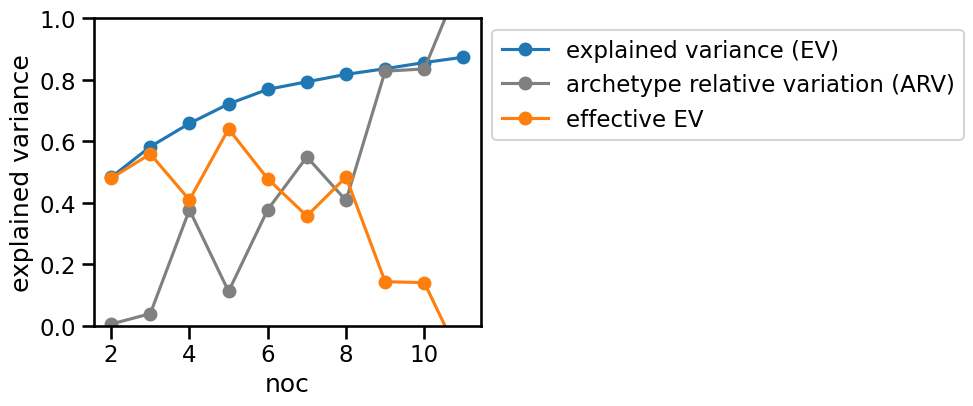

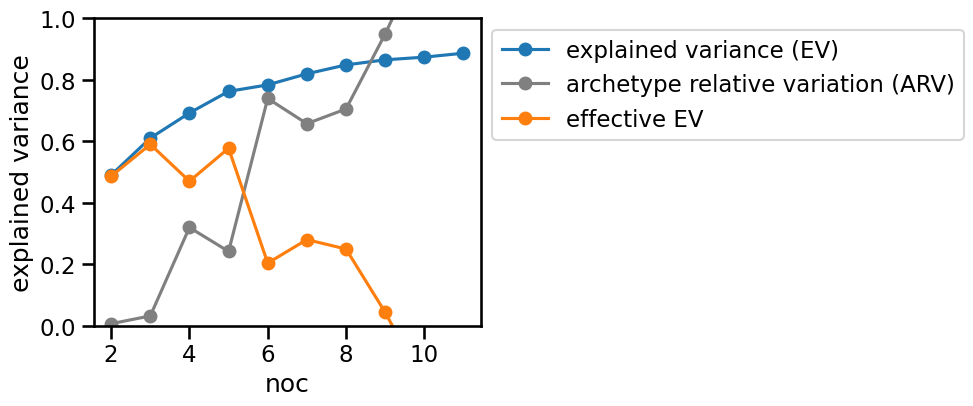

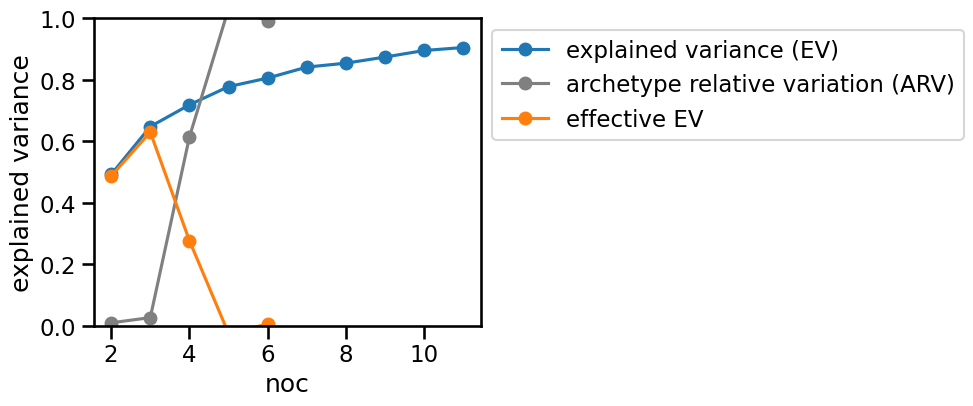

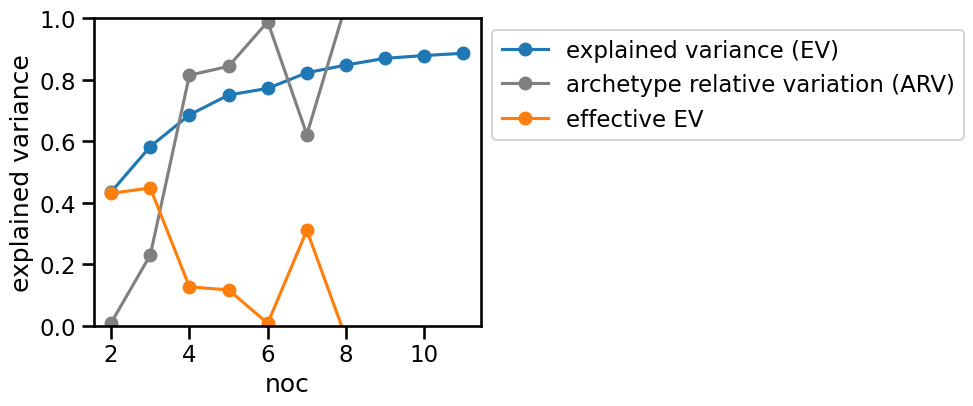

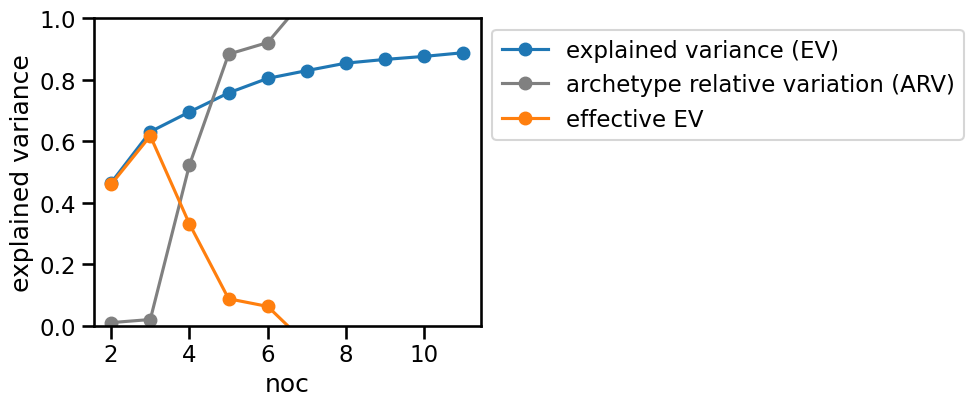

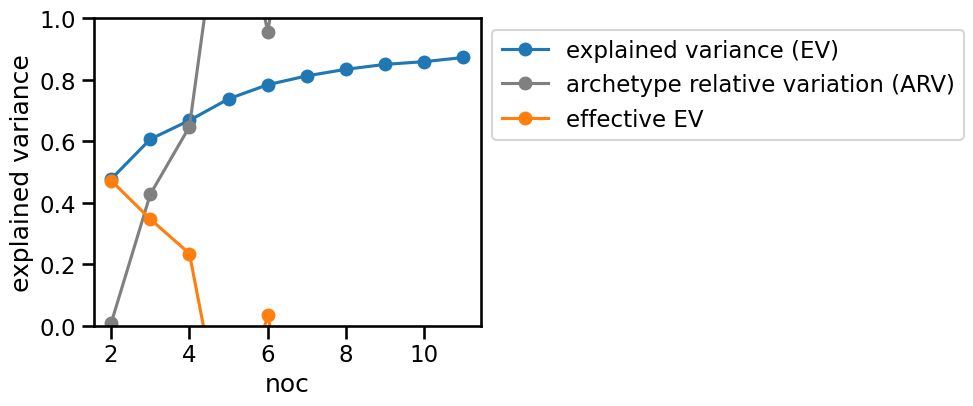

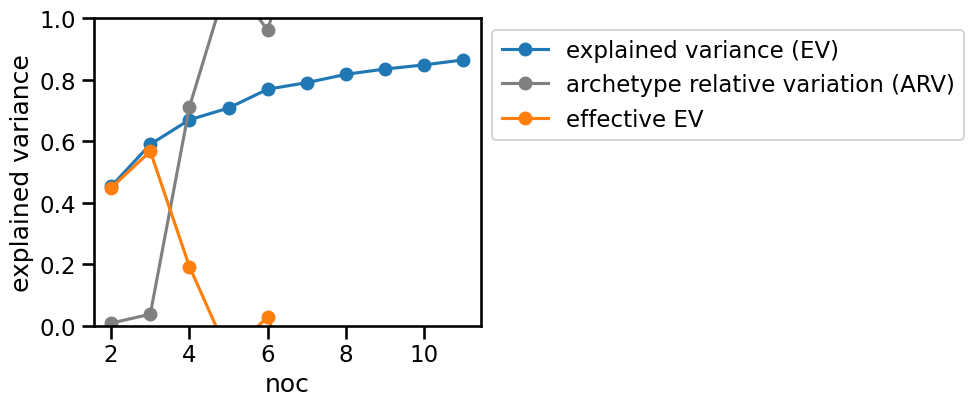

In [4]:
%%time

ev_grid_list = []
av_grid_list = []

ages = ['P6', 'P8', 'P10', 'P12', 'P14', 'P17', 'P21']
for age in ages:
    f_anndata_in  = f"../../data/v1_multiome/run_sca/multiome_l56it_{age}_hvg.h5ad"
    adata_hvg = sc.read(f_anndata_in)
    genes_hvg = adata_hvg.var.index.values
    
    # types = [0]*len(adata_hvg)
    types = adata_hvg.obs.Type.cat.codes
    norm_mat = np.array(adata_hvg.layers['lognorm'])
    sca = SCA(norm_mat, types)

    ndim = 10 
    nrepeats = 10

    np.random.seed(0)

    noc_grid = np.arange(2, ndim+2) 
    ev_grid = []
    av_grid = []

    sca.setup_feature_matrix(method='data')
    for noc in noc_grid:
        xp, aa, ev = sca.proj_and_pcha(ndim, noc)

        aa_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats)
        av = get_relative_variation(aa_boots)

        print(noc, ev, av)
        ev_grid.append(ev)
        av_grid.append(av)

    ev_grid = np.array(ev_grid)
    av_grid = np.array(av_grid)
    
    ev_grid_list.append(ev_grid)
    av_grid_list.append(av_grid)
    
    fig, ax = plt.subplots(1,1,figsize=(1*5,1*4))
    pf = 10

    ax.plot(noc_grid[:pf], ev_grid[:pf], '-o', label='explained variance (EV)')
    ax.plot(noc_grid[:pf], av_grid[:pf], '-o', color='gray', label='archetype relative variation (ARV)')
    ax.plot(noc_grid[:pf], ev_grid[:pf]*(1-av_grid[:pf]), '-o', label='effective EV')
    ax.set_xlabel('noc')
    ax.set_ylabel('explained variance')
    ax.set_ylim([0,1])
    ax.legend(bbox_to_anchor=(1,1))

# one analysis

In [14]:
noc  = 3
ndim = noc-1
nrepeats = 3

In [15]:
# data 
sca.setup_feature_matrix(method='data')
xp, aa, _ = sca.proj_and_pcha(ndim, noc)
aa_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats)

use data


In [16]:
# gshuff
sca.setup_feature_matrix(method='gshuff')
xp_gshuff, aa_gshuff, _ = sca.proj_and_pcha(ndim, noc)
aa_gshuff_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats)

use shuffled data


In [17]:
# tshuff 
sca.setup_feature_matrix(method='tshuff')
xp_tshuff, aa_tshuff, _ = sca.proj_and_pcha(ndim, noc)
aa_tshuff_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats)

use per-type shuffled data


## plot

In [18]:
types_colorvec = np.char.add('C', sca.types_idx.astype(str))

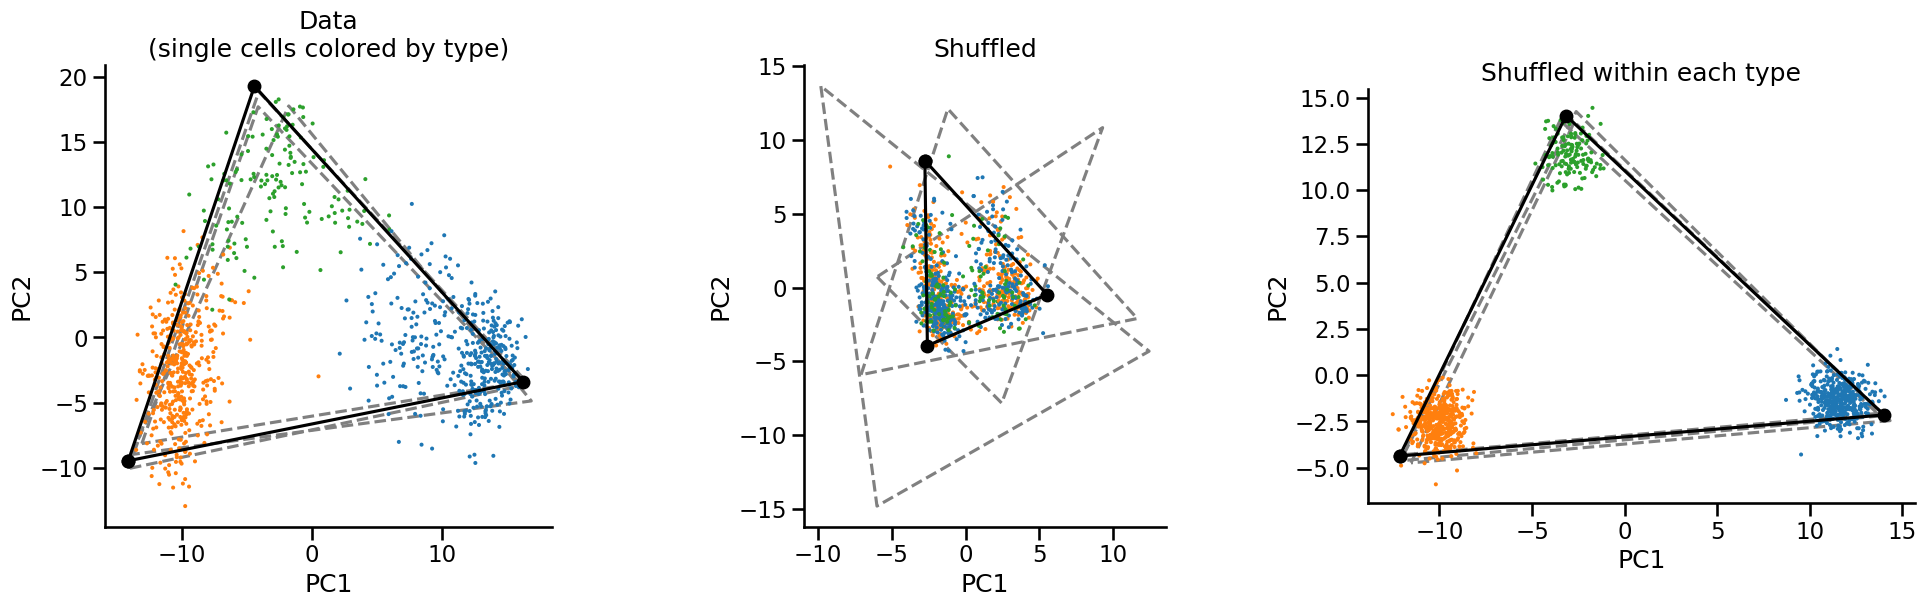

In [19]:
# plot
fig, axs = plt.subplots(1,3,figsize=(8*3,6))
ax = axs[0]
ax.scatter(xp[:,0], xp[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')
    
ax = axs[1]
ax.set_title('Shuffled')
ax.scatter(xp_gshuff[:,0], xp_gshuff[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa_gshuff, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_gshuff_boots[i], fmt='--', color='gray', zorder=0)

ax = axs[2]
ax.set_title('Shuffled within each type')
ax.scatter(xp_tshuff[:,0], xp_tshuff[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa_tshuff, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_tshuff_boots[i], fmt='--', color='gray', zorder=0)

for i in range(3):
    ax = axs[i]
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_aspect('equal')
    sns.despine(ax=ax)
    ax.grid(False)
    
plt.show()

In [20]:
adata_hvg.obs.Type

AAACCGAAGGAGTCGG-1-P21a-2023 Multiome-9-0    L6IT_A
AAACGCGCAAACTGTT-1-P21a-2023 Multiome-9-0    L6IT_A
AAAGCGGGTCTTTGAC-1-P21a-2023 Multiome-9-0    L6IT_A
AACAGATAGCAAGATG-1-P21a-2023 Multiome-9-0    L6IT_A
AACAGATAGTTTGAGC-1-P21a-2023 Multiome-9-0    L6IT_A
                                              ...  
TTACACCGTGTGCACG-1-P21b-2023 Multiome-9-0    L6IT_B
TTCGTTAGTTGTGACA-1-P21b-2023 Multiome-9-0    L6IT_B
TTGCAGCCAAGTTATC-1-P21b-2023 Multiome-9-0    L6IT_B
TTTAAGGTCACAGGAA-1-P21b-2023 Multiome-9-0    L6IT_B
TTTCCTGAGGCGTAAA-1-P21b-2023 Multiome-9-0    L6IT_B
Name: Type, Length: 1013, dtype: category
Categories (3, object): ['L5IT', 'L6IT_A', 'L6IT_B']

## quantify the level of pointedness 
- t-ratio 

In [21]:
t_ratio, t_ratio_shuffs, pval = sca.t_ratio_test(ndim, noc, nrepeats=100)
print(f'p-value: {pval}')

use data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
u

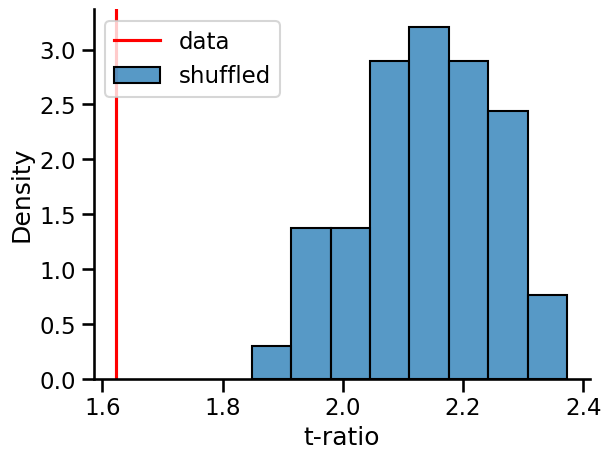

In [22]:
fig, ax = plt.subplots()
ax.axvline(t_ratio, color='r', label='data')
sns.histplot(t_ratio_shuffs, ax=ax, stat='density', label='shuffled')
ax.set_xlabel('t-ratio')
ax.legend()
sns.despine(ax=ax)
plt.show()

# local gradient 

In [23]:
adata_dpt = adata_hvg
adata_dpt.obsm['pca_later'] = PCA(n_components=10).fit_transform(sca.xn)
adata_dpt

AnnData object with n_obs × n_vars = 1013 × 4200
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'cond'
    var: 'feature_types'
    obsm: 'pca_later'
    layers: 'lognorm', 'norm', 'zlognorm'

In [24]:
pc1 = adata_dpt.obsm['pca_later'][:,0]
pc2 = adata_dpt.obsm['pca_later'][:,1]
gexp = np.array(adata_dpt[:,'Cdh13'].layers['norm']).reshape(-1,)

sc.pp.neighbors(adata_dpt, n_neighbors=30, use_rep='pca_later')
# adata_dpt.uns["iroot"] = np.argmax(gexp) 
adata_dpt.uns["iroot"] = np.argmax(-pc1+pc2)
sc.tl.diffmap(adata_dpt)
sc.tl.dpt(adata_dpt)

In [25]:
num_bins = 100
xm = (1/2 + np.arange(0,num_bins,1))*1/num_bins
adata_dpt.obs['dpt'] = np.clip(adata_dpt.obs['dpt_pseudotime'].values, a_min=0, a_max=1)

adata_dpt.obs['dpt_bin']  = pd.cut( adata_dpt.obs['dpt'], num_bins, labels=False)
adata_dpt.obs['dpt_qbin'] = pd.qcut(adata_dpt.obs['dpt'], num_bins, labels=False)

cdf = adata_dpt.obs.groupby('dpt_bin').size()
cdf_by_subclass = adata_dpt.obs.groupby(['dpt_bin', 'Subclass']).size().unstack()

qcdf = adata_dpt.obs.groupby('dpt_qbin').size()
qcdf_by_subclass = adata_dpt.obs.groupby(['dpt_qbin', 'Subclass']).size().unstack()

Text(0.5, 1.0, 'Data\n(single cells colored by type)')

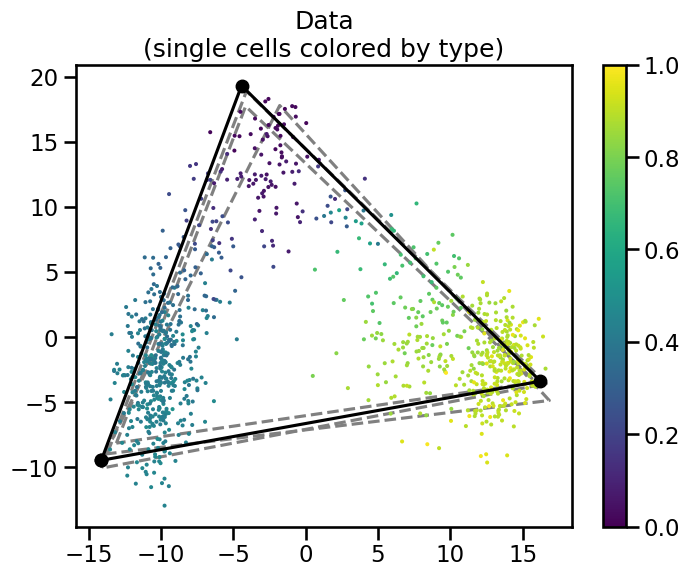

In [26]:
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(xp[:,0], xp[:,1], c=adata_dpt.obs['dpt'].values, s=2)
fig.colorbar(g)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')

Text(0.5, 1.0, 'Data\n(single cells colored by type)')

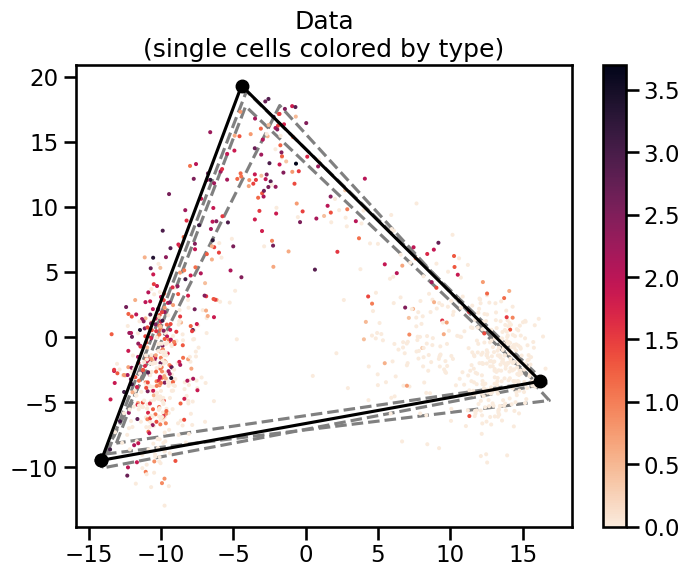

In [27]:
gexp = np.array(adata_dpt[:,'Chrm2'].layers['lognorm']).reshape(-1,)

fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(xp[:,0], xp[:,1], c=gexp, s=2, cmap='rocket_r')
fig.colorbar(g)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')

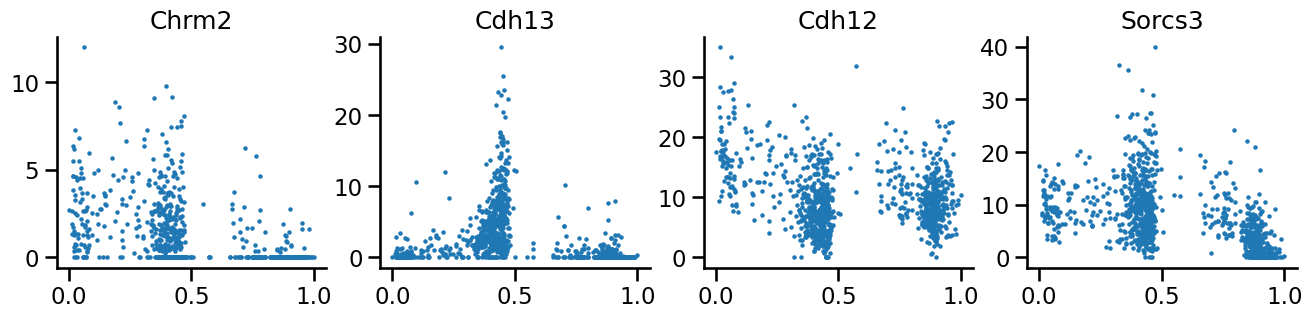

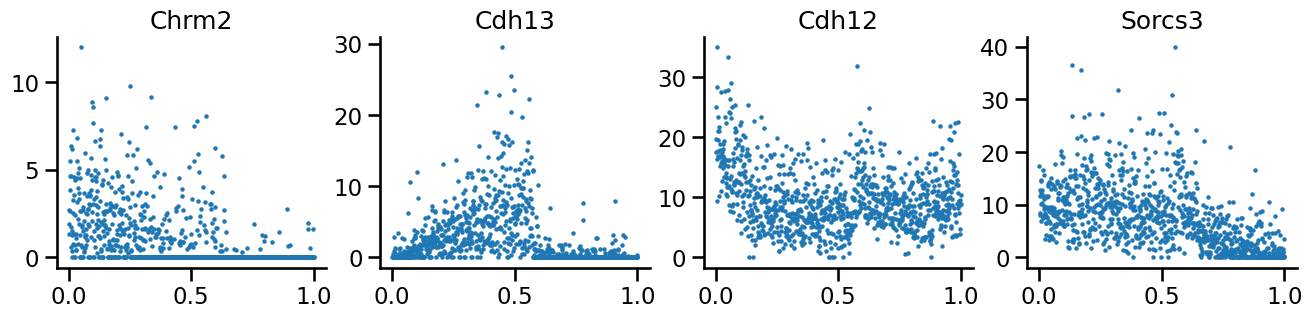

In [28]:
x = adata_dpt.obs['dpt'].values
qx = adata_dpt.obs['dpt'].rank(pct=True)

gns = ['Chrm2', 'Cdh13', 'Cdh12', 'Sorcs3']
n = len(gns)

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.array(adata_dpt[:,gn].layers['norm']).reshape(-1,)
    ax.scatter(x, y, s=3)
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.array(adata_dpt[:,gn].layers['norm']).reshape(-1,)
    ax.scatter(qx, y, s=3)
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()